# Notebook 04: Tariff Pricing Agent

Translates demand forecasts into optimal dynamic per-kWh tariffs.

**Two pricing policies:**
1. **Rule-based** — transparent surge/discount thresholds (PS-aligned): surge when util > 80%, discount when util < 30%
2. **Optimisation-based** — maximises expected revenue `p × D(p)` subject to a congestion penalty, where `D(p) = D₀ × (p/p₀)^ε` using the estimated elasticity

**Baseline**: ₹15/kWh fixed tariff (PS-specified).

**Key documented assumption**: elasticity ε estimated from UrbanEV ¥ data is used as an order-of-magnitude proxy for INR demand response. This bridges the two datasets but is not a calibrated market-specific estimate.

**Outputs → `outputs/`:**
- `tariff_recommendations.csv`: per slot — util, rule tariff, optimal tariff, expected revenue vs baseline
- `tariff_metrics.csv`: Revenue Gain %, Charger Utilisation Rate, Off-Peak Uplift

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path('..') / 'src'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from agents import TariffPricingAgent, estimate_elasticity
from features import BASELINE_TARIFF, SURGE_THRESHOLD, DISCOUNT_THRESHOLD
from metrics import revenue_gain_pct, off_peak_uplift

OUT_DATA = Path('..') / 'data_processed'
OUTPUTS  = Path('..') / 'outputs'
OUT_FIG  = OUTPUTS / 'figures'

sns.set_theme(style='whitegrid', palette='muted')
print('Ready')

Ready


## 1. Estimate Price Elasticity from UrbanEV

In [2]:
uev = pd.read_parquet(OUT_DATA / 'urbanev_featured.parquet')
uev['datetime'] = pd.to_datetime(uev['datetime'])

elasticity = estimate_elasticity(uev, price_col='price', demand_col='volume')
print(f'\nElasticity used by pricing agent: ε = {elasticity:.4f}')
print('Interpretation: a 10% increase in price is associated with a',
      f'{abs(elasticity)*10:.1f}% decrease in volume (log-log OLS estimate).')

Estimated price elasticity (log-log OLS): -2.0188
  Note: proxy estimate from UrbanEV ¥ data; not a causal INR elasticity.

Elasticity used by pricing agent: ε = -2.0188
Interpretation: a 10% increase in price is associated with a 20.2% decrease in volume (log-log OLS estimate).


## 2. Apply Pricing Policies to Demand Predictions

In [3]:
preds = pd.read_csv(OUTPUTS / 'demand_predictions.csv')
print(f'Predictions loaded: {preds.shape}')
print(f'Datasets: {preds["dataset"].value_counts().to_dict()}')
preds.head(3)

Predictions loaded: (429513, 12)
Datasets: {'urbanev': 426816, 'acn': 2697}


/var/folders/q5/qzzxzszs1194f6vdymzlkyqc0000gn/T/ipykernel_31374/2703316937.py:1: DtypeWarning: Columns (0: entity_id) have mixed types. Specify dtype option on import or set low_memory=False.
  preds = pd.read_csv(OUTPUTS / 'demand_predictions.csv')


,timestamp,entity_id,datetime,hour,dow,utilization_rate,volume,congested,pred_utilization,pred_load,pred_congestion_prob,dataset
0,6913.0,1000,2022-07-13 00:00:00,0,2,0.341969,25.375000,0,0.343624,25.632015,0.000002,urbanev
1,6914.0,1000,2022-07-13 00:05:00,0,2,0.347150,25.573333,0,0.343624,25.602964,0.000002,urbanev
2,6915.0,1000,2022-07-13 00:10:00,0,2,0.347150,25.666667,0,0.346563,25.602964,0.000002,urbanev


In [4]:
agent = TariffPricingAgent(elasticity=elasticity)

# Apply to all predictions
recs = agent.recommend(preds, demand_col='pred_load')

print('Tariff distribution (rule-based):')
print(recs['tariff_rule'].describe().round(2))
print('\nTariff distribution (optimised):')
print(recs['tariff_optimal'].describe().round(2))

Tariff distribution (rule-based):
count    429513.00
mean         13.58
std           1.90
min           9.00
25%          12.33
50%          14.24
75%          15.00
max          23.91
Name: tariff_rule, dtype: float64

Tariff distribution (optimised):
count    429513.00
mean          9.77
std           1.45
min           9.00
25%           9.00
50%           9.00
75%           9.89
max          24.00
Name: tariff_optimal, dtype: float64


## 3. Revenue Gain Analysis

In [5]:
# Fix column name after recommend() (it prefixes rev_ for both)
# re-derive cleanly
recs['rev_rule'] = recs['pred_load'] * recs['tariff_rule']
recs['rev_optimal'] = recs['pred_load'] * recs['tariff_optimal']
recs['rev_baseline'] = recs['pred_load'] * BASELINE_TARIFF

# Aggregate by dataset
for ds in ['urbanev', 'acn']:
    sub = recs[recs['dataset'] == ds]
    total_base = sub['rev_baseline'].sum()
    gain_rule = revenue_gain_pct(sub['rev_rule'].sum(), total_base)
    gain_opt  = revenue_gain_pct(sub['rev_optimal'].sum(), total_base)
    print(f'{ds.upper()}:')
    print(f'  Baseline revenue  : {total_base:,.1f}')
    print(f'  Revenue Gain (rule-based)  : {gain_rule:+.2f}%')
    print(f'  Revenue Gain (optimised)   : {gain_opt:+.2f}%')

URBANEV:
  Baseline revenue  : 260,077,087.5
  Revenue Gain (rule-based)  : -1.54%
  Revenue Gain (optimised)   : -37.20%
ACN:
  Baseline revenue  : 40,760.7
  Revenue Gain (rule-based)  : +41.74%
  Revenue Gain (optimised)   : +8.20%


## 4. Utilisation Before vs After Dynamic Pricing

In [6]:
# Simulated post-pricing utilisation: util scales with demand response
# D_new = D_base * (tariff/15)^ε  =>  util_new = util_old * (D_new/D_base)

eps = elasticity
recs['util_after_rule'] = (recs['pred_utilization'] *
    (recs['tariff_rule'] / BASELINE_TARIFF) ** eps).clip(0, 1)
recs['util_after_opt']  = (recs['pred_utilization'] *
    (recs['tariff_optimal'] / BASELINE_TARIFF) ** eps).clip(0, 1)

# Peak periods
recs['is_peak_flag'] = recs.get('is_peak', recs.get('hour', pd.Series(dtype=float)).isin(range(7,21))).astype(bool) if 'is_peak' in recs.columns else False

print('Utilisation summary (all slots):')
print(f'  Before (predicted)     : {recs["pred_utilization"].mean():.3f}')
print(f'  After rule-based       : {recs["util_after_rule"].mean():.3f}')
print(f'  After optimised        : {recs["util_after_opt"].mean():.3f}')
print(f'\nFraction surge-zone (>80%) before: {(recs["pred_utilization"]>0.8).mean():.1%}')
print(f'Fraction surge-zone (>80%) after rule: {(recs["util_after_rule"]>0.8).mean():.1%}')

Utilisation summary (all slots):
  Before (predicted)     : 0.295
  After rule-based       : 0.324
  After optimised        : 0.630

Fraction surge-zone (>80%) before: 1.7%
Fraction surge-zone (>80%) after rule: 0.0%


## 5. Off-Peak Uplift

In [7]:
uplift_rule = off_peak_uplift(
    recs['pred_load'],
    recs['pred_load'] * (recs['tariff_rule']/BASELINE_TARIFF)**eps,
    recs['pred_utilization']
)
print(f'Off-peak session uplift (rule-based): {uplift_rule:+.3f} kWh/slot avg increase')

Off-peak session uplift (rule-based): +3.787 kWh/slot avg increase


## 6. Tariff Heatmap by Hour & Utilisation

/var/folders/q5/qzzxzszs1194f6vdymzlkyqc0000gn/T/ipykernel_31374/1116110304.py:40: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/q5/qzzxzszs1194f6vdymzlkyqc0000gn/T/ipykernel_31374/1116110304.py:41: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  plt.savefig(OUT_FIG / 'tariff_agent_results.png', dpi=150)
/Users/prnb/Desktop/socbiz/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


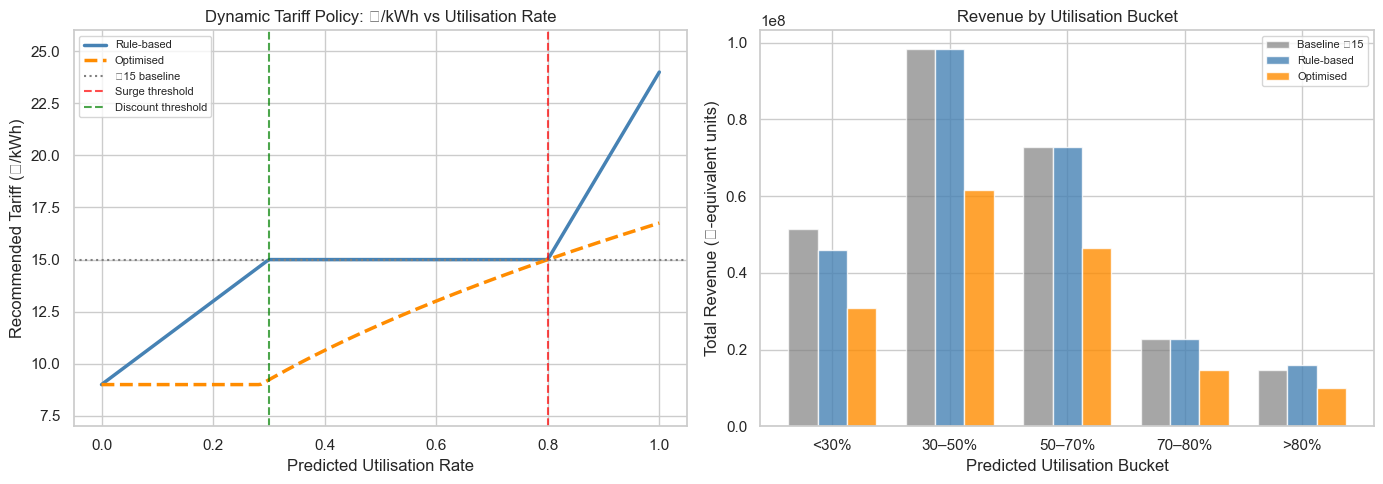

In [8]:
# Rule-based tariff as function of utilisation (deterministic)
util_vals = np.linspace(0, 1, 200)
tariff_curve = [agent.rule_based_tariff(u) for u in util_vals]
opt_curve    = [agent.optimal_tariff(u, 10.0) for u in util_vals]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(util_vals, tariff_curve, lw=2.5, color='steelblue', label='Rule-based')
axes[0].plot(util_vals, opt_curve, lw=2.5, color='darkorange', linestyle='--', label='Optimised')
axes[0].axhline(BASELINE_TARIFF, color='grey', linestyle=':', lw=1.5, label='₹15 baseline')
axes[0].axvline(SURGE_THRESHOLD, color='red', linestyle='--', lw=1.5, alpha=0.7, label='Surge threshold')
axes[0].axvline(DISCOUNT_THRESHOLD, color='green', linestyle='--', lw=1.5, alpha=0.7, label='Discount threshold')
axes[0].set_title('Dynamic Tariff Policy: ₹/kWh vs Utilisation Rate', fontsize=12)
axes[0].set_xlabel('Predicted Utilisation Rate')
axes[0].set_ylabel('Recommended Tariff (₹/kWh)')
axes[0].set_ylim(7, 26)
axes[0].legend(fontsize=8)

# Revenue comparison by utilisation bucket
recs['util_bucket'] = pd.cut(recs['pred_utilization'], bins=[0,0.3,0.5,0.7,0.8,1.0],
                              labels=['<30%','30–50%','50–70%','70–80%','>80%'])
rev_compare = recs.groupby('util_bucket', observed=True).agg(
    rev_base=('rev_baseline','sum'),
    rev_rule=('rev_rule','sum'),
    rev_opt=('rev_optimal','sum'),
).reset_index()

x = np.arange(len(rev_compare))
w = 0.25
axes[1].bar(x-w, rev_compare['rev_base'], w, label='Baseline ₹15', color='grey', alpha=0.7)
axes[1].bar(x,   rev_compare['rev_rule'], w, label='Rule-based', color='steelblue', alpha=0.8)
axes[1].bar(x+w, rev_compare['rev_opt'],  w, label='Optimised', color='darkorange', alpha=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(rev_compare['util_bucket'].astype(str))
axes[1].set_title('Revenue by Utilisation Bucket', fontsize=12)
axes[1].set_xlabel('Predicted Utilisation Bucket')
axes[1].set_ylabel('Total Revenue (₹-equivalent units)')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(OUT_FIG / 'tariff_agent_results.png', dpi=150)
plt.show()

## 7. Export Outputs

In [9]:
recs.to_csv(OUTPUTS / 'tariff_recommendations.csv', index=False)
print(f'Saved tariff_recommendations.csv: {len(recs):,} rows')

# Metrics summary
tariff_metrics = []
for ds in ['urbanev','acn']:
    sub = recs[recs['dataset'] == ds]
    tariff_metrics.append({
        'dataset': ds,
        'baseline_revenue': sub['rev_baseline'].sum(),
        'rule_revenue': sub['rev_rule'].sum(),
        'opt_revenue': sub['rev_optimal'].sum(),
        'revenue_gain_pct_rule': revenue_gain_pct(sub['rev_rule'].sum(), sub['rev_baseline'].sum()),
        'revenue_gain_pct_opt': revenue_gain_pct(sub['rev_optimal'].sum(), sub['rev_baseline'].sum()),
        'mean_util_before': sub['pred_utilization'].mean(),
        'mean_util_after_rule': sub['util_after_rule'].mean(),
        'pct_surge_before': (sub['pred_utilization']>0.8).mean(),
        'pct_surge_after_rule': (sub['util_after_rule']>0.8).mean(),
        'elasticity_used': eps,
    })

pd.DataFrame(tariff_metrics).to_csv(OUTPUTS / 'tariff_metrics.csv', index=False)
print('Saved tariff_metrics.csv')
pd.DataFrame(tariff_metrics).round(4)

Saved tariff_recommendations.csv: 429,513 rows
Saved tariff_metrics.csv


,dataset,baseline_revenue,rule_revenue,opt_revenue,revenue_gain_pct_rule,revenue_gain_pct_opt,mean_util_before,mean_util_after_rule,pct_surge_before,pct_surge_after_rule,elasticity_used
0,urbanev,2.600771e+08,2.560740e+08,1.633230e+08,-1.5392,-37.2021,0.2908,0.3235,0.0112,0.0,-2.0188
1,acn,4.076070e+04,5.777235e+04,4.410245e+04,41.7354,8.1985,0.9387,0.4726,0.9855,0.0,-2.0188
